### **Model for Genotypes**

In a simple model of inheritance, a given person has one of three genotypes: $AA$, $Aa$, or $aa$. Each person possesses two alleles, each of which is either $A$ or $a$. We assume the first and second alleles are inherited independently and are identically distributed (i.i.d.).

**Let $\theta$ represent the probability of inheriting allele $A$**. Since the order of alleles does not matter ($Aa$ is equivalent to $aA$), **the probabilities** are: $P(AA) = \theta^2, \quad P(aa) = (1 - \theta)^2, \quad P(Aa) = P(Aa \cup aA) = 2\theta(1 - \theta)$. Alternatively, using the complement rule: $P(Aa) = 1 - P(AA) - P(aa) = 1 - \theta^2 - (1 - \theta)^2 = 2\theta(1 - \theta)$.

**The Random Vector $X$**: We define a random vector $X \in \{0,1\}^3$ associated with a person’s genotype $g$ such that:
- $X =
\begin{cases}
(1, 0, 0) & \text{if } g = AA \\
(0, 1, 0) & \text{if } g = aa \\
(0, 0, 1) & \text{if } g = Aa
\end{cases}$

The Probability Mass Function (**PMF**) **$p(x)$ for the vector** $X = (x_1, x_2, x_3)$ over the set of possible outcomes $\{(1,0,0), (0,1,0), (0,0,1)\}$ is given by:
- $p(x) =
\begin{cases}
\theta^2 & \text{for } x = (1, 0, 0) \\
(1 - \theta)^2 & \text{for } x = (0, 1, 0) \\
2\theta(1 - \theta) & \text{for } x = (0, 0, 1)
\end{cases}$

**Rewrite using the components of $x$** as: $p(x) = (\theta^2)^{x_1} \cdot ((1 - \theta)^2)^{x_2} \cdot (2\theta(1 - \theta))^{x_3}$


### **MLE for Genotypes (Hardy-Weinberg Equilibrium)**

A sample of 942 males from Zimbabwe was collected, and the following genotypes were observed: 501 of type AA, 83 of type aa, and 358 of type Aa.  We aim to compute the Maximum Likelihood Estimate, $\hat{\theta}_{MLE}$ for the allele frequency $\theta$.
- Given Data $N_{AA} = 501$, $N_{aa} = 83$, $N_{Aa} = 358$. Total sample size $n = N_{AA} + N_{aa} + N_{Aa} = 942$


**The Likelihood Function**:
Under Hardy-Weinberg Equilibrium, the probabilities for the genotypes are $P(AA) = \theta^2$, \quad $P(aa) = (1-\theta)^2$, and $P(Aa) = 2\theta(1-\theta)$.
- $L(\theta)$ $L(\theta) = (\theta^2)^{N_{AA}} \cdot ((1-\theta)^2)^{N_{aa}} \cdot (2\theta(1-\theta))^{N_{Aa}}$

**The Log-Likelihood Function**: Taking the logarithm to simplify the derivation:
- $\ell(\theta) = 2N_{AA} \ln(\theta) + 2N_{aa} \ln(1-\theta) + N_{Aa} \ln(2\theta(1-\theta))$, and expanding the last term  $\ell(\theta) = (2N_{AA} + N_{Aa}) \ln(\theta) + (2N_{aa} + N_{Aa}) \ln(1-\theta) + N_{Aa} \ln(2)$.


**Derivation and Solving for $\theta$:** To find the MLE, we take the derivative with respect to $\theta$ and set it to zero: $\frac{d\ell}{d\theta} = \frac{2N_{AA} + N_{Aa}}{\theta} - \frac{2N_{aa} + N_{Aa}}{1-\theta} = 0$

**Rearranging the equation**: $\frac{2N_{AA} + N_{Aa}}{\theta} = \frac{2N_{aa} + N_{Aa}}{1-\theta}$ ;  $(2N_{AA} + N_{Aa})(1 - {\theta}) = (2N_{aa} + N_{Aa}){\theta}$

**Solving for $\theta$**: $\hat{\theta} = \frac{2N_{AA} + N_{Aa}}{2(N_{AA} + N_{aa} + N_{Aa})}$

**Numerical Calculation** - Plugging in the observed values $\hat{\theta} = \frac{2(501) + 358}{2(501 + 83 + 358)} = \frac{1002 + 358}{2(942)} = \frac{1360}{1884} \approx 0.7219$

### **Implementation**

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [10]:
# Observed counts from the Zimbabwe study, and total number of individuals
n_AA_zim, n_aa_zim, n_Aa_zim = 501, 83, 358
total_n = n_AA_zim + n_aa_zim + n_Aa_zim

# Calculate the MLE for theta
theta_hat_zim = (2 * n_AA_zim + n_Aa_zim) / (2 * total_n)

print(f'Zimbabwe Study Genotype Counts:AA={n_AA_zim},aa={n_aa_zim},Aa={n_Aa_zim} \nTotal Individuals: {total_n} \nMLE estimate (theta_hat): {theta_hat_zim:.4f}')

Zimbabwe Study Genotype Counts:AA=501,aa=83,Aa=358 
Total Individuals: 942 
MLE estimate (theta_hat): 0.7219


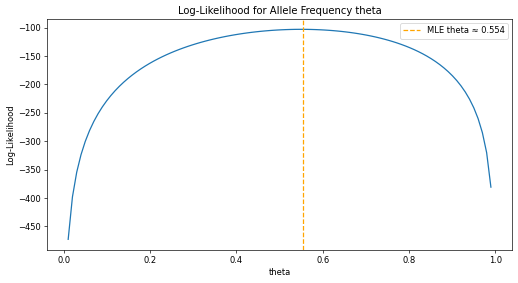

Observed Counts [AA, aa, Aa]: [30 20 50] 
Estimated theta (MLE): 0.5544


In [11]:
'''
p(x|theta) = (theta^2)^x1 * ((1-theta)^2)^x2 * (2*theta*(1-theta))^x3
ln(p) = x1*2*ln(theta) + x2*2*ln(1-theta) + x3*(ln(2) +ln(theta) + ln(1-theta))
small epsilon to avoid log(0)
'''
def log_likelihood(theta, counts):
    n_AA, n_aa, n_Aa = counts
    eps = 1e-10
    theta = np.clip(theta, eps, 1 - eps)
    ll = n_AA * 2 * np.log(theta) + n_aa * 2 * np.log(1 - theta) + \
         n_Aa * (np.log(2) + np.log(theta) + np.log(1 - theta))
    return ll

# Simulated data: 100 people, counts for [AA, aa, Aa]
observed_counts = np.array([30, 20, 50])
theta_vals = np.linspace(0.01, 0.99, 100)
likelihoods = [log_likelihood(t, observed_counts) for t in theta_vals]

mle_theta = theta_vals[np.argmax(likelihoods)]

plt.figure(figsize=(10, 5), dpi=60)
plt.plot(theta_vals, likelihoods)
plt.axvline(mle_theta, color='orange', linestyle='--', label=f'MLE theta ≈ {mle_theta:.3f}')
plt.title('Log-Likelihood for Allele Frequency theta')
plt.xlabel('theta') ; plt.ylabel('Log-Likelihood')
plt.legend() ; plt.show()

print(f'Observed Counts [AA, aa, Aa]: {observed_counts} \nEstimated theta (MLE): {mle_theta:.4f}')

The expected allele frequency (MLE) can be calculated directly by counting the 'A' alleles: Each **AA** individual has 2 'A' alleles, Each **Aa** individual has 1 'A' allele, and each **aa** individual has 0 'A' alleles.
- $\hat{\theta} = \frac{2 \cdot n_{AA} + 1 \cdot n_{Aa}}{2 \cdot (n_{AA} + n_{aa} + n_{Aa})}$

In [ ]:
# Calculate analytical MLE
n_AA, n_aa, n_Aa = observed_counts
total_individuals = n_AA + n_aa + n_Aa
analytical_theta = (2 * n_AA + n_Aa) / (2 * total_individuals)

print( f'Observed Counts: AA={n_AA}, aa={n_aa}, Aa={n_Aa} \n'
       f'Analytical MLE theta: {analytical_theta}')

Observed Counts: AA=30, aa=20, Aa=50
Analytical MLE theta: 0.55


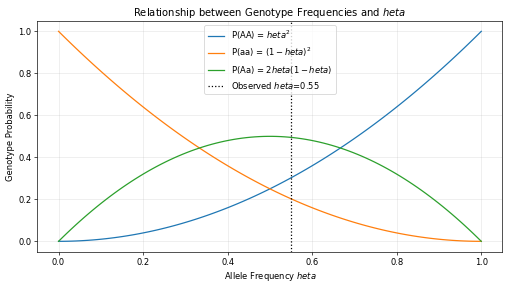

In [ ]:
theta_range = np.linspace(0, 1, 100)

plt.figure(figsize=(10, 5), dpi =60)
plt.plot(theta_range, theta_range**2, label='P(AA) = ${\theta}^2$')
plt.plot(theta_range, (1-theta_range)**2, label='P(aa) = $(1-\theta)^2$')
plt.plot(theta_range, 2*theta_range*(1-theta_range), label='P(Aa) = $2\theta(1-\theta)$')

plt.axvline(analytical_theta, color='black', linestyle=':', label=f'Observed $\theta$={analytical_theta}')
plt.title('Relationship between Genotype Frequencies and $\theta$')
plt.xlabel('Allele Frequency $\theta$')
plt.ylabel('Genotype Probability')
plt.legend() ; plt.grid(True, alpha=0.3) ; plt.show()

Data from the comparison table

In [14]:
# Hardy-Weinberg Expected Frequencies
p_AA_E, p_aa_E, p_Aa_E = theta_hat_zim**2, (1 - theta_hat_zim)**2, 2 * theta_hat_zim * (1 - theta_hat_zim)

# Expected Counts (Frequency * Total N)
E_AA, E_aa, E_Aa = p_AA_E * total_n, p_aa_E * total_n, p_Aa_E * total_n

# Comparison Table
data = {
    'Genotype': ['AA', 'aa', 'Aa'],
    'Observed': [n_AA_zim, n_aa_zim, n_Aa_zim],
    'Expected': [E_AA, E_aa, E_Aa],
    'Difference': [n_AA_zim - E_AA, n_aa_zim - E_aa, n_Aa_zim - E_Aa] }

df_comp = pd.DataFrame(data)
display(df_comp)

print(f'\nInterpretation: The MLE of {theta_hat_zim:.4f} signifies that approximately 72.19% of the alleles in this pool are \'A\'.')
print('The closeness of Observed and Expected counts suggests how well the population follows Hardy-Weinberg equilibrium.')

,Genotype,Observed,Expected,Difference
0,AA,501,490.870488,10.129512
1,aa,83,72.870488,10.129512
2,Aa,358,378.259023,-20.259023



Interpretation: The MLE of 0.7219 signifies that approximately 72.19% of the alleles in this pool are 'A'.
The closeness of Observed and Expected counts suggests how well the population follows Hardy-Weinberg equilibrium.


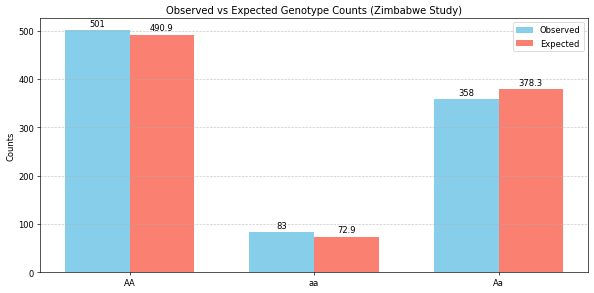

In [27]:
genotypes, observed, expected = df_comp['Genotype'], df_comp['Observed'], df_comp['Expected']

x = np.arange(len(genotypes))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5), dpi=60)
rects1 = ax.bar(x - width/2, observed, width, label='Observed', color='skyblue')
rects2 = ax.bar(x + width/2, expected, width, label='Expected', color='salmon')

ax.set_ylabel('Counts')
ax.set_title('Observed vs Expected Genotype Counts (Zimbabwe Study)')
ax.set_xticks(x) ; ax.set_xticklabels(genotypes) ; ax.legend()

ax.bar_label(rects1, padding=3) ; ax.bar_label(rects2, padding=3, fmt='%.1f')

fig.tight_layout() ; plt.grid(axis='y', linestyle='--', alpha=0.7) ; plt.show()

#### **Chi-Squared Test for Hardy-Weinberg Equilibrium**

The Chi-squared ($\chi^2$) test is used to test the null hypothesis that a population is in Hardy-Weinberg Equilibrium.

#### **Formula**
$\chi^2 = \sum \frac{(O_i - E_i)^2}{E_i}$, where $O_i$ is the Observed count for genotype $i$, and $E_i$ is the Expected count for genotype $i$.

#### **Degrees of Freedom**
For HWE testing with 3 genotypes and 1 estimated parameter ($\theta$), the degrees of freedom ($df$) is
$df = (\text{number of genotypes}) - (\text{number of estimated parameters}) - 1 = 3 - 1 - 1 = 1$.

#### **Interpretation**
- If the calculated $\chi^2$ is greater than the critical value (3.841 for $\alpha=0.05$ and $df=1$), we reject the null hypothesis and conclude the population is **not** in HWE.
- A high p-value ($>0.05$) suggests that the observed differences are likely due to chance alone.

In [26]:
from scipy.stats import chi2

# Calculate Chi-Squared statistic
chi_sq_stat = ((df_comp['Observed'] - df_comp['Expected'])**2 / df_comp['Expected']).sum()

# Degrees of freedom for HWE is typically 1 (3 genotypes - 1 parameter estimated - 1)
df = 1

# Calculate p-value
p_value = 1 - chi2.cdf(chi_sq_stat, df)

print(f'Chi-Squared Statistic: {chi_sq_stat:.4f} \nDegrees of Freedom: {df} \nP-value: {p_value:.4f}')

if p_value < 0.05:
    print('Result: Statistically significant (Reject HWE null hypothesis)')
else:
    print('Result: Not statistically significant (Fail to reject HWE null hypothesis)')

Chi-Squared Statistic: 2.7021 
Degrees of Freedom: 1 
P-value: 0.1002
Result: Not statistically significant (Fail to reject HWE null hypothesis)


#### What does the MLE of 0.7219 signify?

1. **Allele Prevalence**: It tells us that in this specific population sample from Zimbabwe, the 'A' allele is dominant in frequency, accounting for ~72.2% of the total alleles, while the 'a' allele accounts for the remaining ~27.8%.
2. **Predictive Power**: Under the assumption of random mating (Hardy-Weinberg Equilibrium), this single value $\hat{\theta}$ allows us to predict the distribution of genotypes ($AA, aa, Aa$) across the entire population.

### **Template For Generic Approach**

Analyze the genetic dataset from the Zimbabwe study ($N_{AA}=501, N_{aa}=83, N_{Aa}=358$) to assess its consistency with the Hardy-Weinberg Equilibrium (HWE) model, that involves:
1.  **Defining the Model**: Establishing the genotype probability mass function (PMF) and visualizing the relationship between allele frequency $\theta$ and genotype probabilities ($AA, aa, Aa$).
2.  **MLE Estimation**: Deriving the log-likelihood function and calculating the MLE for the allele frequency $\theta$ using the Zimbabwe dataset.
3.  **HWE Comparison**: Calculating the expected genotype counts based on the MLE and creating a visual comparison (bar chart) of observed vs. expected counts.
4.  **Statistical Testing**: Performing a Chi-squared test for HWE, interpreting the resulting p-value (approximately 0.1002), and summarizing whether the population is in statistical equilibrium.
5. **Methodological Extension**: Provide a detailed description of how to perform a Case-Control study, covering participant selection, genotyping, the 2x2 contingency table, and the calculation/interpretation of the Odds Ratio (OR).

#### **Model Definition**
Establish the genotype PMF and visualize the relationship between allele frequency theta and genotype probabilities AA, aa, and Aa.


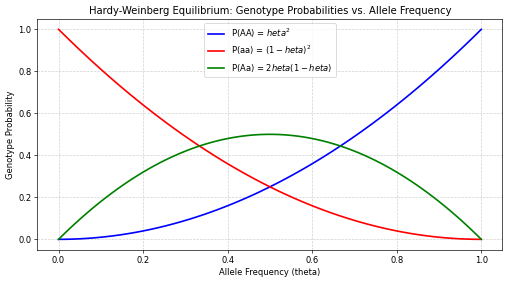

Genotype probabilities calculated and visualized successfully.


In [17]:
# Define range of theta values from 0 to 1
theta_vals = np.linspace(0, 1, 100)

# Calculate genotype probabilities based on Hardy-Weinberg formulas
p_AA, p_aa, p_Aa = theta_vals**2, (1 - theta_vals)**2, 2 * theta_vals * (1 - theta_vals)

# The visualization
plt.figure(figsize=(10, 5), dpi=60)
plt.plot(theta_vals, p_AA, label='P(AA) = $\theta^2$', color='b', linewidth=2)
plt.plot(theta_vals, p_aa, label='P(aa) = $(1-\theta)^2$', color='r', linewidth=2)
plt.plot(theta_vals, p_Aa, label='P(Aa) = $2\theta(1-\theta)$', color='g', linewidth=2)

plt.xlabel('Allele Frequency (theta)') ; plt.ylabel('Genotype Probability')
plt.title('Hardy-Weinberg Equilibrium: Genotype Probabilities vs. Allele Frequency')
plt.legend() ; plt.grid(True, linestyle='--', alpha=0.6) ; plt.show()

print(f'Genotype probabilities calculated and visualized successfully.')

#### **MLE Theory and Implementation**

We provide above the mathematical derivation of the log-likelihood function and implement a numerical MLE search using simulated data.

**Recap: Log-Likelihood Derivation** for Hardy-Weinberg

Given the allele frequency $\theta$ for allele 'A', the probabilities for the genotypes are $P(AA) = \theta^2$, $P(aa) = (1-\theta)^2$, $P(Aa) = 2\theta(1-\theta)$

For observed counts $n_{AA}, n_{aa}, n_{Aa}$, the Likelihood function $L(\theta)$ is given by $L(\theta) = (\theta^2)^{n_{AA}} \cdot ((1-\theta)^2)^{n_{aa}} \cdot (2\theta(1-\theta))^{n_{Aa}}$

Taking the log to get the Log-Likelihood of $\ell(\theta)$, $\ell(\theta) = n_{AA} \ln(\theta^2) + n_{aa} \ln((1-\theta)^2) + n_{Aa} \ln(2\theta(1-\theta))$

Expanding the terms $\ell(\theta) = 2n_{AA} \ln(\theta) + 2n_{aa} \ln(1-\theta) + n_{Aa} [\ln(2) + \ln(\theta) + \ln(1-\theta)]$

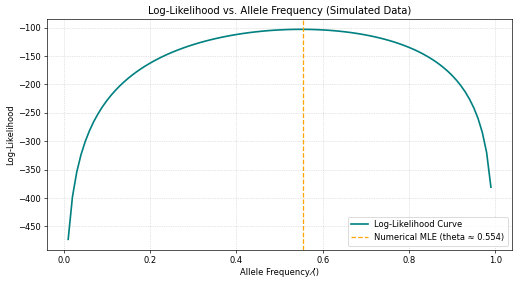

Simulated Counts [AA, aa, Aa]: [30 20 50] 
Numerical MLE for theta: 0.5544


In [20]:
def calculate_log_likelihood(theta, counts):
    n_AA, n_aa, n_Aa = counts # counts: [n_AA, n_aa, n_Aa]
    eps = 1e-10 # Small epsilon to avoid log(0)
    theta = np.clip(theta, eps, 1 - eps)

    # Log-likelihood formula derived in the markdown cell
    ll = (2 * n_AA * np.log(theta) + 2 * n_aa * np.log(1 - theta) +
          n_Aa * (np.log(2) + np.log(theta) + np.log(1 - theta)))
    return ll

# Define simulated genotype counts
simulated_counts = np.array([30, 20, 50])

# Generate range of theta values and compute log-likelihoods
theta_range = np.linspace(0.01, 0.99, 100)
ll_values = [calculate_log_likelihood(t, simulated_counts) for t in theta_range]

# Identify numerical MLE
numerical_mle_theta = theta_range[np.argmax(ll_values)]

# Plot the log-likelihood curve
plt.figure(figsize=(10, 5), dpi=60)
plt.plot(theta_range, ll_values, label='Log-Likelihood Curve', color='teal', linewidth=2)
plt.axvline(numerical_mle_theta, color='orange', linestyle='--',
            label=f'Numerical MLE (theta ≈ {numerical_mle_theta:.3f})')

plt.title('Log-Likelihood vs. Allele Frequency (Simulated Data)')
plt.xlabel('Allele Frequency (̸)') ; plt.ylabel('Log-Likelihood')
plt.legend() ; plt.grid(True, linestyle=':', alpha=0.7) ; plt.show()

print(f'Simulated Counts [AA, aa, Aa]: {simulated_counts} \nNumerical MLE for theta: {numerical_mle_theta:.4f}')

#### **Case Study Analysis**

Calculate the analytical MLE for the Zimbabwe dataset (N_AA=501, N_aa=83, N_Aa=358 - the allele frequency using the specific genotype counts) and interpret the result.

In [24]:
# Define observed genotype counts for the Zimbabwe study
n_AA_zim, n_aa_zim, n_Aa_zim = 501, 83, 358

# Calculate the total number of individuals
total_n_zim = n_AA_zim + n_aa_zim + n_Aa_zim

# Apply the analytical MLE of theta, theta_hat =(2 * n_AA + n_Aa)/(2 * total_n)
theta_hat_zim = (2 * n_AA_zim + n_Aa_zim) / (2 * total_n_zim)

print(f'Total Individuals in Zimbabwe Study: {total_n_zim} \nAnalytical MLE (theta_hat): {theta_hat_zim:.4f} \n \nInterpretation: The MLE of {theta_hat_zim:.4f} indicates that the \'A\' allele is quite prevalent \nin this Zimbabwe population sample, accounting for approximately {theta_hat_zim*100:.2f}% of the total \nalleles in the gene pool.')

Total Individuals in Zimbabwe Study: 942 
Analytical MLE (theta_hat): 0.7219 
 
Interpretation: The MLE of 0.7219 indicates that the 'A' allele is quite prevalent 
in this Zimbabwe population sample, accounting for approximately 72.19% of the total 
alleles in the gene pool.


#### **HWE Comparison and Visualization**

Calculate expected genotype counts based on the MLE and render a bar chart comparing observed vs. expected counts to assess Hardy-Weinberg Equilibrium fit.


#### **Statistical Significance Testing**

Perform the Chi-squared test for HWE, interpret the p-value, and discuss broader genetic association tests.


In [25]:
from scipy.stats import chi2

# Calculate Chi-Squared statistic using df_comp (the Zimbabwe study data)
chi_sq_stat = ((df_comp['Observed'] - df_comp['Expected'])**2 / df_comp['Expected']).sum()

# Degrees of freedom for HWE is 1 (3 genotypes - 1 parameter (theta) - 1)
df = 1

# Calculate p-value using the survival function (1 - cdf)
p_value = 1 - chi2.cdf(chi_sq_stat, df)

print(f'Chi-Squared Statistic: {chi_sq_stat:.4f} \nDegrees of Freedom: {df} \nP-value: {p_value:.4f}')

# Conclusion at alpha = 0.05
alpha = 0.05
if p_value < alpha:
    print(f'Result: Statistically significant (p < {alpha}). Reject HWE null hypothesis.')
else:
    print(f'Result: Not statistically significant (p >= {alpha}). Fail to reject HWE null hypothesis.')

Chi-Squared Statistic: 2.7021 
Degrees of Freedom: 1 
P-value: 0.1002
Result: Not statistically significant (p >= 0.05). Fail to reject HWE null hypothesis.


#### **Interpretation of the Chi-squared Test Results**

- **P-value Analysis**: The calculated p-value of **0.1002** is greater than the standard significance level ($\alpha = 0.05$).
- **Conclusion**: We fail to reject the null hypothesis. This indicates that the observed genotype counts in the Zimbabwe dataset do not deviate significantly from the proportions expected under Hardy-Weinberg Equilibrium. Any observed differences are likely due to sampling variation rather than evolutionary forces like selection or non-random mating.

#### **Other Common Genetic Association Tests**

Beyond HWE testing, researchers utilize several other statistical methods to understand genetic traits and disease associations:
1. **Case-Control Association Tests**: Uses Chi-squared or Fisher's Exact tests to compare allele or genotype frequencies between a group with a trait (cases) and a healthy group (controls).
2. **Logistic Regression**: Used to model the probability of a binary outcome (e.g., disease presence) as a function of the number of risk alleles (0, 1, or 2) while adjusting for covariates like age or sex.
3. **Transmission Disequilibrium Test (TDT)**: A family-based test that checks if a specific allele is transmitted from parents to affected offspring more frequently than expected by chance, effectively controlling for population stratification.

#### **Methodological Insights**
- **Case-Control Studies**: We defined the methodology for identifying genetic risk factors by comparing cases (diseased) and controls (healthy).
- **Odds Ratio (OR)**: A key metric derived from the 2x2 contingency table.
  - $OR > 1$ implies a risk factor.
  - $OR < 1$ implies a protective factor.
  - $OR = 1$ implies no association.

#### **Q&A**

**How consistent is the Zimbabwe population data with the Hardy-Weinberg Equilibrium (HWE) model?**
The Zimbabwe population dataset is statistically consistent with the HWE model. The calculated p-value of **0.1002** exceeds the standard significance threshold ($\alpha = 0.05$), meaning we fail to reject the null hypothesis. The observed genotype counts do not deviate significantly from the expected proportions.

**What is the estimated allele frequency for the Zimbabwe study?**
The Maximum Likelihood Estimate (MLE) for the frequency of the 'A' allele ($\hat{\theta}$) is **0.7219**, indicating that the 'A' allele accounts for approximately **72.19%** of the total gene pool in the sampled population.

**How are Case-Control studies interpreted** using the Odds Ratio (OR)? An  OR>1  suggests the allele is a risk factor, an  OR<1  suggests a protective effect, and an OR=1  indicates no association with the disease.

#### **Data Analysis Key Findings**
-   **Sample Composition**: The study analyzed a total of **942 individuals**, with observed counts of 501 ($AA$), 83 ($aa$), and 358 ($Aa$).
-   **Expected vs. Observed Counts**: Based on the calculated allele frequency ($\hat{\theta} \approx 0.7219$), the HWE model predicted counts of approximately 490.9 ($AA$), 72.9 ($aa$), and 378.2 ($Aa$).
-   **Deviation Patterns**: The observed data showed a slight excess of both homozygous genotypes ($AA$ and $aa$) and a slight deficit of heterozygotes ($Aa$) compared to the model, but these differences were not statistically significant.
-   **Statistical Metrics**: The Chi-squared statistic was **2.7021** with **1** degree of freedom, leading to the p-value of **0.1002**.

#### **Insights or Next Steps**
-   **Further Research:** To delve deeper into genetic associations, the next steps could include performing **Case-Control Association Tests** or **Logistic Regression** to see if these genotypes correlate with specific phenotypic traits or diseases within the Zimbabwe population.
